In [489]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import scipy.stats as stats
from scipy.stats import shapiro, mannwhitneyu, ttest_ind

In [490]:
df = pd.read_csv('website_ab_test.csv')

<h2>Preprocessing</h2>

In [491]:
df.isna().sum()

Theme                 0
Click Through Rate    0
Conversion Rate       0
Bounce Rate           0
Scroll_Depth          0
Age                   0
Location              0
Session_Duration      0
Purchases             0
Added_to_Cart         0
dtype: int64

In [492]:
df.describe()

,Click Through Rate,Conversion Rate,Bounce Rate,Scroll_Depth,Age,Session_Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.256048,0.253312,0.505758,50.319494,41.528000,924.999000
std,0.139265,0.139092,0.172195,16.895269,14.114334,508.231723
min,0.010767,0.010881,0.200720,20.011738,18.000000,38.000000
25%,0.140794,0.131564,0.353609,35.655167,29.000000,466.500000
50%,0.253715,0.252823,0.514049,51.130712,42.000000,931.000000
75%,0.370674,0.373040,0.648557,64.666258,54.000000,1375.250000
max,0.499989,0.498916,0.799658,79.997108,65.000000,1797.000000


In [493]:
df = pd.concat((df, pd.get_dummies(df['Location'], drop_first=True)), axis=1)

In [494]:
df['Purchases'] = df['Purchases'].apply(lambda x: True if x=='Yes' else False)
df['Added_to_Cart'] = df['Added_to_Cart'].apply(lambda x: True if x=='Yes' else False)

<p>There are non null values, and the data description indicates that outliers are rare or non existant. This is supported by the fact that the max values are all roughly within 2 standard deviations of the mean. Therefore, no further data preprocessing needs to be done </p>

<h2>Analyzing By Age</h2>

In [495]:
age_df = df.copy(deep=True)

In [496]:
bins = [18,28,48,65]
labels_list = ['18 to 25 year olds', '28 to 48 year olds','48 to 65 year olds']

In [497]:
age_df.Age = pd.cut(age_df.Age, bins, labels = labels_list)

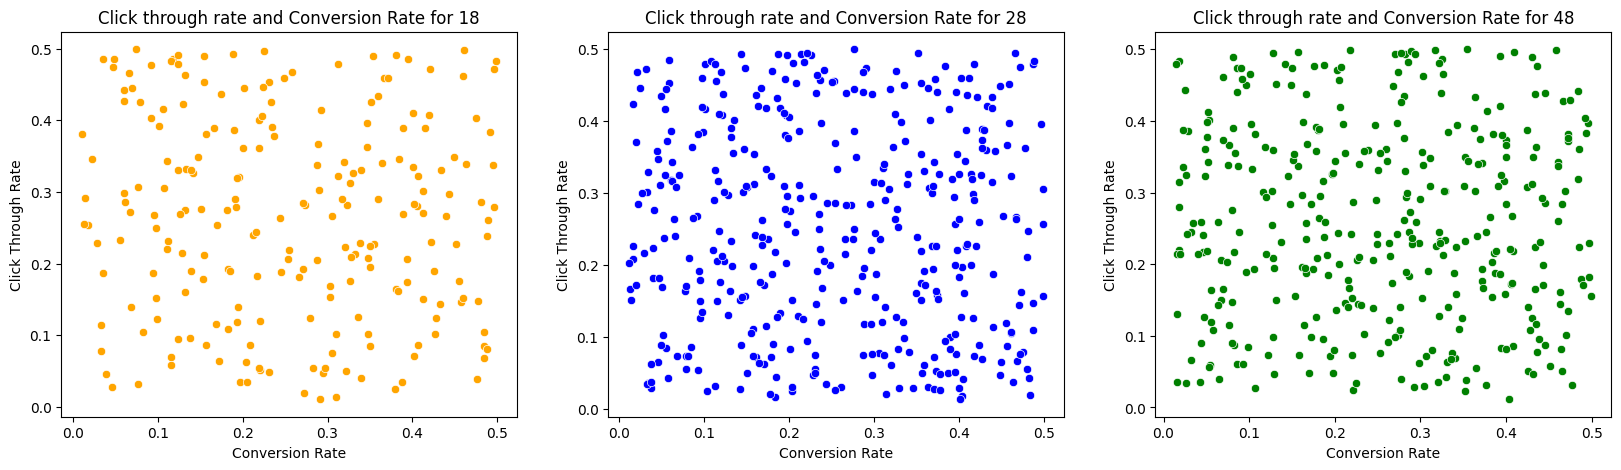

In [498]:
fig, axes = plt.subplots(1,3, figsize=(20,5))
colors = ['orange','blue','green']
for count ,label in enumerate(labels_list):
    sns.scatterplot(age_df[age_df.Age==label], x='Conversion Rate', y='Click Through Rate', ax=axes[count],color=colors[count]).set_title(f'Click through rate and Conversion Rate for {bins[count]}')

In [499]:
age_df[age_df.Age==labels_list[2]].iloc[:,0:5].describe(),age_df[age_df.Age==labels_list[2]].iloc[:,0:5].describe(),age_df[age_df.Age==labels_list[2]].iloc[:,0:5].describe()

(       Click Through Rate  Conversion Rate  Bounce Rate  Scroll_Depth
 count          360.000000       360.000000   360.000000    360.000000
 mean             0.258135         0.253482     0.517032     50.447873
 std              0.135382         0.139293     0.177920     17.042362
 min              0.011478         0.014701     0.201318     20.328167
 25%              0.149191         0.131384     0.368511     35.967484
 50%              0.244355         0.262783     0.529628     50.396993
 75%              0.364070         0.371488     0.668705     65.021225
 max              0.499989         0.498609     0.799658     79.760824,
        Click Through Rate  Conversion Rate  Bounce Rate  Scroll_Depth
 count          360.000000       360.000000   360.000000    360.000000
 mean             0.258135         0.253482     0.517032     50.447873
 std              0.135382         0.139293     0.177920     17.042362
 min              0.011478         0.014701     0.201318     20.328167
 25% 

<hr>
<p>Similiar statistics across age groups indicate that the demographic of age has no significant impact on factors such as click through rate, depth of scroll, and conversion rate. This means that age is not a significant factor to consider when changing the website, as it is currently equally catering to all age groups</p>
<hr>

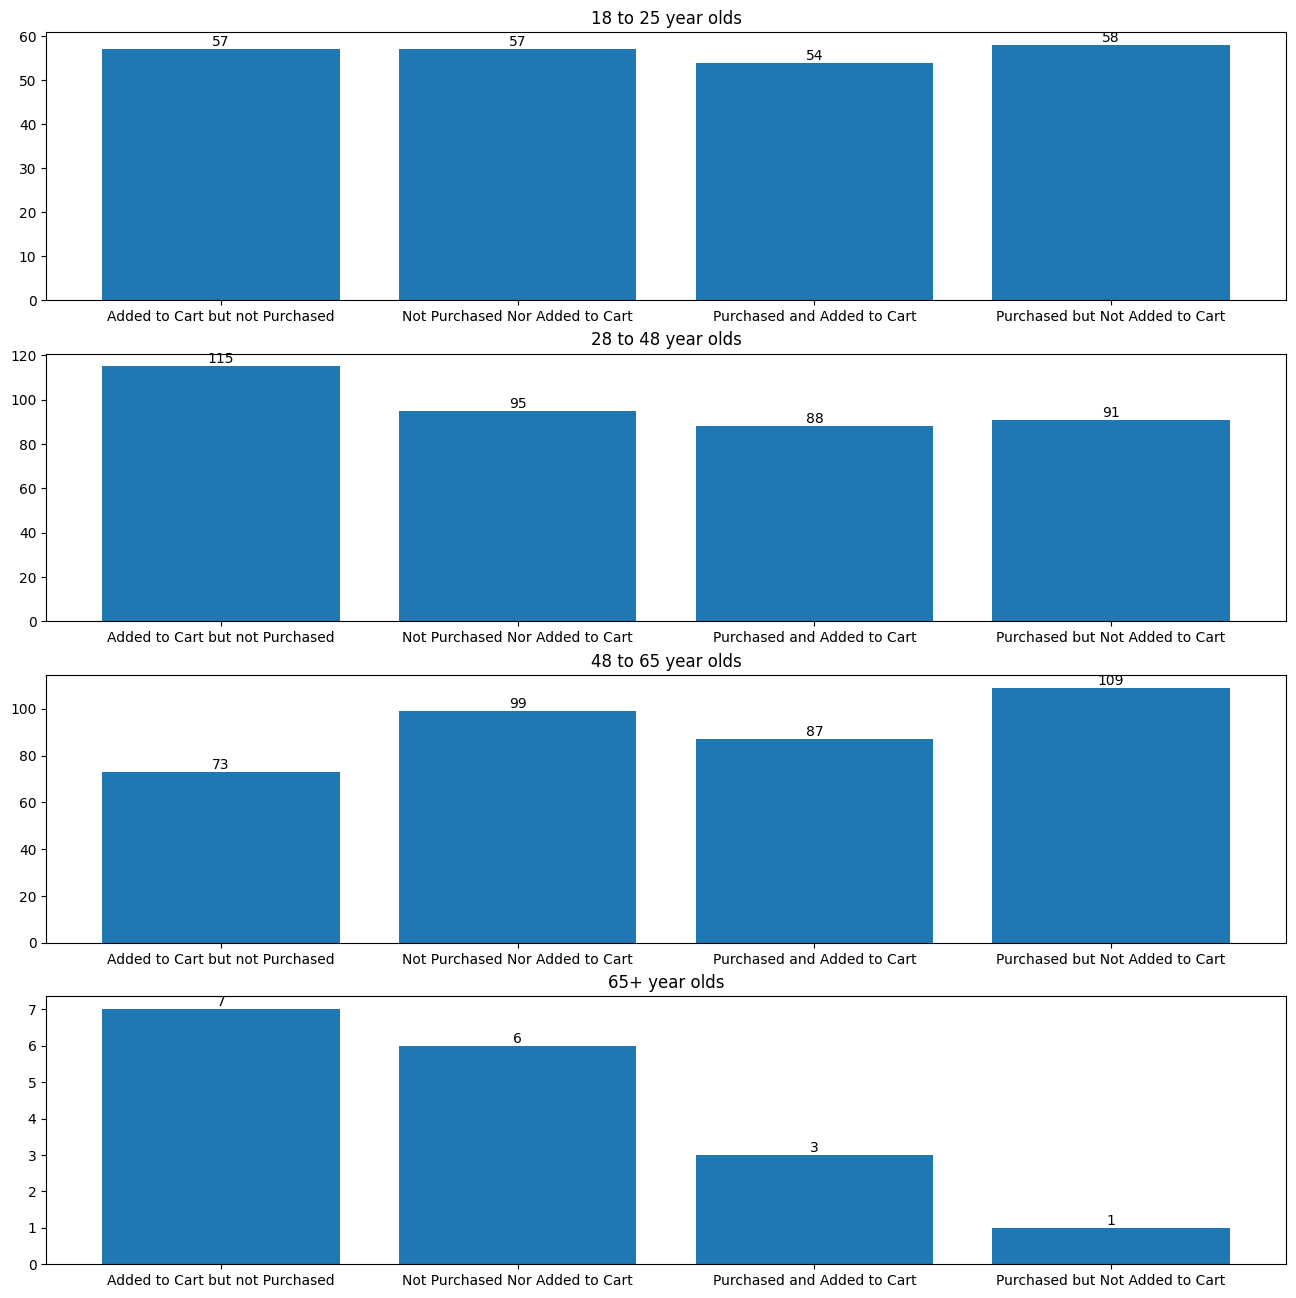

In [501]:
fig, axes = plt.subplots(4,1, figsize=(16,16))
age_cat_df = df.copy(deep=True)
graph_labels = ['18 to 25 year olds', '28 to 48 year olds','48 to 65 year olds','65+ year olds']
def evaluate_purchases_and_cart(row):
        if row['Purchases'] and row['Added_to_Cart']:
            return "Purchased and Added to Cart"  
        elif row['Purchases'] and not row['Added_to_Cart']:
            return "Purchased but Not Added to Cart" 
        elif not row['Purchases'] and row['Added_to_Cart']:
            return "Added to Cart but not Purchased"
        else:
            return "Not Purchased Nor Added to Cart"
x_labels_order = ['Added to Cart but not Purchased', 'Purchased and Added to Cart',
       'Purchased but Not Added to Cart',
       'Not Purchased Nor Added to Cart']
age_cat_df['purchase_cart_category'] = age_cat_df.apply(evaluate_purchases_and_cart, axis=1)
for count, range_num in enumerate(bins):
    
    per_age_cat_df = None;
    if count==len(bins)-1:
        per_age_cat_df = age_cat_df[age_cat_df['Age']>=range_num] 
    else:
        per_age_cat_df = age_cat_df[(age_cat_df['Age']>=range_num) & (age_cat_df['Age']<bins[count+1])] 

    x_labels = per_age_cat_df['purchase_cart_category'].unique()
    x_labels = np.sort(x_labels)
    y_labels = per_age_cat_df['purchase_cart_category'].value_counts(sort=False).values
    
    bars = axes[count].bar(x_labels, y_labels)
    axes[count].bar_label(bars)
    axes[count].set_title(graph_labels[count])


<p>There does not seem to be much of a significant correlation between adding a product to the cart and ultimately purchasing it across age groups. However, its noteworthy that the 48 to 65 year old age groups are less likely to purchase a product they've added to their cart and more likely to make purchases without adding to the cart, indicating a certin level of impulsivity. Therefore, it may be beneficial for the website owners to send marketing campaigns targetting members of this age demographic with limited time BOGOF sales or campaigns focusing on specific products to take advantage of their impulsivity</p>
<hr>

<h5>Further Analysis</h5>

In [502]:
age_df.groupby('Age')['Purchases'].mean()

C:\Users\ravin.DESKTOP-KNR8KT1\AppData\Local\Temp\ipykernel_25768\1726005007.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_df.groupby('Age')['Purchases'].mean()


Age
18 to 25 year olds    0.495455
28 to 48 year olds    0.535176
48 to 65 year olds    0.511111
Name: Purchases, dtype: float64

In [503]:
age_df[['Age','Session_Duration']].groupby('Age', observed=False).mean()

,Session_Duration
Age,
18 to 25 year olds,908.318182
28 to 48 year olds,926.226131
48 to 65 year olds,934.444444


In [504]:
age_df.iloc[:,1:6].groupby('Age', observed=False).mean()

,Click Through Rate,Conversion Rate,Bounce Rate,Scroll_Depth
Age,,,,
18 to 25 year olds,0.264774,0.256303,0.493930,50.630627
28 to 48 year olds,0.250675,0.252554,0.503032,49.829374
48 to 65 year olds,0.258135,0.253482,0.517032,50.447873


<hr>
There is no significant effect on age on session duration and purchases
<hr>

<h2>Analyzing By Theme</h2>

<p> Testing Hypothesis that the theme will have a significant effect on user actions and/or has strong correlations with their demographics</p>

In [505]:
theme_df = df.copy(deep=True)

In [506]:
theme_continous = pd.concat([theme_df.iloc[:,0:5],theme_df['Session_Duration']], axis=1)

In [507]:
theme_continous.groupby('Theme').mean()

,Click Through Rate,Conversion Rate,Bounce Rate,Scroll_Depth,Session_Duration
Theme,,,,,
Dark Theme,0.264501,0.251282,0.512115,49.926404,919.482490
Light Theme,0.247109,0.255459,0.499035,50.735232,930.833333


In [508]:
theme_categorical = theme_df.select_dtypes('object').drop('Location', axis=1)

In [509]:
theme_categorical.groupby('Theme').value_counts()

Theme
Dark Theme     514
Light Theme    486
Name: count, dtype: int64

<p>The above code ran a description of the values of individual columns when grouped by theme. As can be seen, there are no significant differences when comparing the means for light and dark theme across multiple features. It doesn't seem to have an effect on categorical data such as whether purchases were made or were added to cart, as values don't seem to differ significantly amongst them. Overall, it can be said that dark or light themes have little to no significant effect on user activity</p>

In [511]:
pd.read_csv('website_ab_test.csv').columns

Index(['Theme', 'Click Through Rate', 'Conversion Rate', 'Bounce Rate',
       'Scroll_Depth', 'Age', 'Location', 'Session_Duration', 'Purchases',
       'Added_to_Cart'],
      dtype='object')

<Axes: xlabel='Bounce Rate', ylabel='Click Through Rate'>

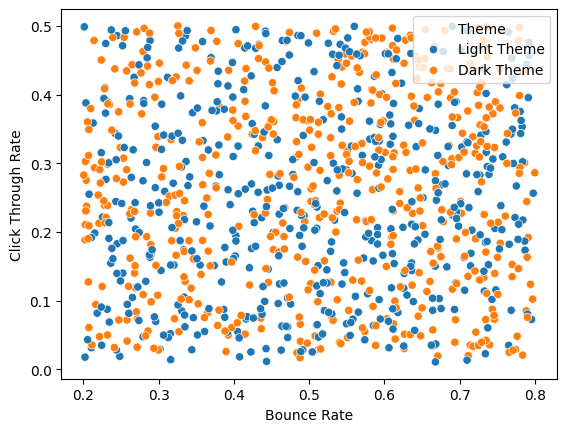

In [512]:
sns.scatterplot(data=df, x='Bounce Rate',y='Click Through Rate', hue='Theme')

In [513]:
filtered_df = df.copy(deep=True)

In [514]:
filtered_df['Theme']=filtered_df['Theme'].apply(lambda x: 1 if x== 'Dark Theme' else 0)
X_train, X_test, y_train, y_test = train_test_split(filtered_df[['Bounce Rate','Conversion Rate']], filtered_df.Theme, stratify=filtered_df.Theme, test_size=0.3)

In [515]:
params = {
    'C': [1.0,5.0,10.0],
    'kernel': ['linear','poly','rbf', 'sigmoid'],
    'degree': [3,4,5],
    'gamma': ['scale','auto']
}

In [516]:
cv = GridSearchCV(svm.SVC(), params)
cv.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [1.0, 5.0, ...], 'degree': [3, 4, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'poly', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10.0


In [517]:
cv.score(X_test,y_test)

0.47333333333333333

<p>Even with the most optimal parameters, the model still has very weak accuracy, indicating that website theme doesnt have much of an impact on bounce rates or conversion rates
</p>
<hr>

<Axes: xlabel='Theme', ylabel='Session_Duration'>

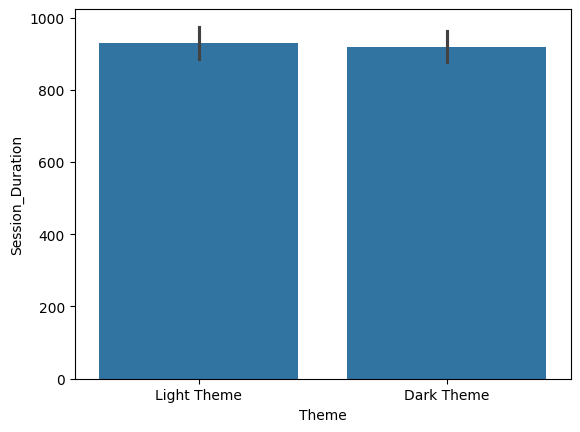

In [518]:
sns.barplot(data=df, x='Theme',y='Session_Duration')

In [519]:
df.groupby('Theme')['Session_Duration'].mean()
#no impact of theme on session duration

Theme
Dark Theme     919.482490
Light Theme    930.833333
Name: Session_Duration, dtype: float64

In [520]:
df.groupby('Theme')[['Click Through Rate', 'Conversion Rate', 'Bounce Rate', 'Age']].mean()
#no impact of theme on features click through rate conversion rate, bounce rate and age

,Click Through Rate,Conversion Rate,Bounce Rate,Age
Theme,,,,
Dark Theme,0.264501,0.251282,0.512115,41.332685
Light Theme,0.247109,0.255459,0.499035,41.734568


<p><b>Overall, we can conclude that website theme has little to no impact on a users behaviour on the website</b></p>
<hr>

<h2>Analyzing By Location</h2>

Text(48.34119791666667, 0.5, 'Amount of Users Using the Theme')

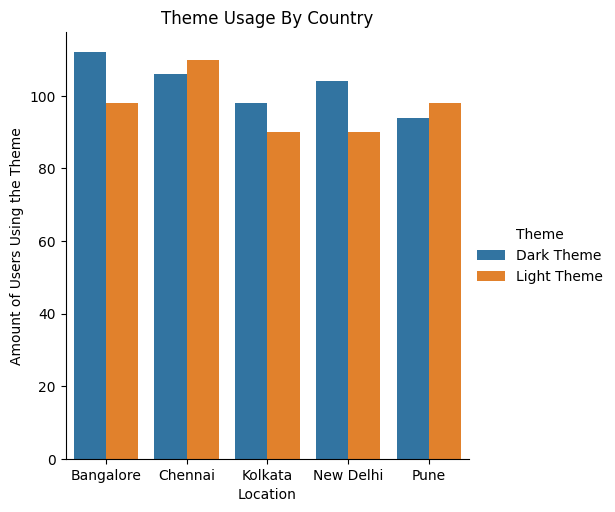

In [521]:
sns.catplot(
    data=df.groupby(['Location','Theme'], as_index=False).count().iloc[:,0:3],
    kind='bar',
    x='Location',
    y='Click Through Rate',
    hue='Theme',
)
plt.title('Theme Usage By Country')
plt.ylabel('Amount of Users Using the Theme')

<p>As seen above, with the slight exception of bangalore, users across locations do not seem to have a special preference for any color theme in particular</p>

In [522]:
location_grouped_with_purchases = df.groupby('Location')['Purchases'].mean()
location_grouped_with_purchases

Location
Bangalore    0.461905
Chennai      0.550926
Kolkata      0.574468
New Delhi    0.479381
Pune         0.520833
Name: Purchases, dtype: float64

<p>Considering that there's an approximately 10% gap between purchase rates of countries like Kolkata and Chennai and countries like New Delhi and Bangalore, it seems intuitive to statistically test this to check if this difference is statistically significant to warrant any actions taken by the company on it</p>

<b>H0: There is no significant difference between the purchase rates of the countries</b><br>
<b>H1: There is a significant difference between the purchase rates of the countries</b>

In [523]:
print(f'p value of {np.round(shapiro(location_grouped_with_purchases.values).pvalue, 3)}>0.5 therefore the data can be assumed to be normal allowing for statistical measures relying on normality of data to be used')

p value of 0.743>0.5 therefore the data can be assumed to be normal allowing for statistical measures relying on normality of data to be used


In [524]:
purchases_for_delhi_bangalore =location_grouped_with_purchases[['Bangalore','New Delhi']]
purchases_for_kolkata_chennai = location_grouped_with_purchases[['Kolkata','Chennai']]
U_stat, p_val = mannwhitneyu(purchases_for_delhi_bangalore, purchases_for_kolkata_chennai, method="exact", alternative='two-sided')
print("p-value:", p_val)

p-value: 0.3333333333333333


In [525]:
t_stat, p_val = ttest_ind(purchases_for_delhi_bangalore, purchases_for_kolkata_chennai, equal_var=False, alternative='two-sided')
print("p-value:", p_val)

p-value: 0.029633836423809554


Both p values are greater than 0.05, meaning there is little evidence to indicate that there is a significant difference in the purchase rates of the countries; we cannot reject H0

In [544]:
age_df.iloc[:, 1:7].drop('Age', axis=1).groupby('Location').mean()

,Click Through Rate,Conversion Rate,Bounce Rate,Scroll_Depth
Location,,,,
Bangalore,0.247903,0.252739,0.508473,49.994379
Chennai,0.246745,0.241762,0.511132,50.760181
Kolkata,0.256593,0.262407,0.475561,50.331115
New Delhi,0.251679,0.256417,0.516967,50.919421
Pune,0.279305,0.254890,0.514984,49.561762


In [547]:
age_df[['Location','Added_to_Cart']].groupby('Location').mean()

,Added_to_Cart
Location,
Bangalore,0.585714
Chennai,0.537037
Kolkata,0.500000
New Delhi,0.510309
Pune,0.489583


<p>It seems that the users location does not have much of an effect on their behaviour on the website. Within context, it would mean that the company of the ecommerce site will not have to focus too much on user location demographics when making decisions such as marketing campaigns</p>

<h2>Conclusions</h2>

<p>Age has no significant impact on user behaviour, such as bounce rate or conversion rates, indicated by similiar statistics across age groups. It is worth mentioning that the 48 to 65 year old age groups are less likely to purchase a product they've added to their cart and more likely to make purchases without adding to the cart, indicating a certin level of impulsivity. Therefore, it may be beneficial for the website owners to send marketing campaigns targetting members of this age demographic with limited time BOGOF sales or campaigns focusing on specific products to take advantage of their impulsivity </p>
<p>Website theme has no impact on user behavior</p>
<p>User location also does not seem to have a significant impact on user behaviour. <i>However</i>, it is possible that users in Kolkata and Chennai make more purchases than users in New Delhi and Bangalore; though there is no significant evidence for this, the percentage gap certainly warrants further investigation</p>
